# VELOCIDAD DEL VIENTO

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

# Estilo visual
sns.set(style="whitegrid")

url = "https://raw.githubusercontent.com/lihkir/Data/main/wind_speed/data_treino_dv_df_2000_2010.csv"

df = pd.read_csv(url,s encoding="utf-8")

df.columns = [
    "HORA_UTC",                      # HORA (UTC)
    "DIRECCION_VIENTO_GR",          # VENTO, DIREÇÃO HORARIA (gr)
    "VELOCIDAD_VIENTO_MS",          # VENTO, VELOCIDADE HORARIA (m/s)
    "HUMEDAD_MAX_ANT",              # UMIDADE REL. MAX. NA HORA ANT. (AUT)
    "HUMEDAD_MIN_ANT",              # UMIDADE REL. MIN. NA HORA ANT. (AUT)
    "TEMP_MAX_ANT_C",               # TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)
    "TEMP_MIN_ANT_C",               # TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)
    "HUMEDAD_HORARIA",              # UMIDADE RELATIVA DO AR, HORARIA
    "PRESION_HORARIA",              # PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA
    "PRECIPITACION_TOTAL",          # PRECIPITAÇÃO TOTAL, HORÁRIO
    "RAJADA_MAX_VIENTO_MS",         # VENTO, RAJADA MAXIMA (m/s)
    "PRESION_MAX_ANT",              # PRESSÃO ATMOSFERICA MAX.NA HORA ANT.
    "PRESION_MIN_ANT"               # PRESSÃO ATMOSFERICA MIN. NA HORA ANT.
]



In [2]:
# RESUMEN GENERAL
print(f"Dimensiones: {df.shape}")
print("\nTipos de variables:\n", df.dtypes.value_counts())

# Separar tipos de variables
tipos = df.dtypes.value_counts()
print("Resumen de tipos de variables:")
print(tipos)

# Mostrar cada columna con su tipo específico
print("\nTipo de cada columna:\n")
print(df.dtypes)

# Mostrar nombres largos para reducir
long_columns = [col for col in df.columns if len(col) > 25]
long_columns

Dimensiones: (87693, 13)

Tipos de variables:
 float64    12
object      1
Name: count, dtype: int64
Resumen de tipos de variables:
float64    12
object      1
Name: count, dtype: int64

Tipo de cada columna:

HORA_UTC                 object
DIRECCION_VIENTO_GR     float64
VELOCIDAD_VIENTO_MS     float64
HUMEDAD_MAX_ANT         float64
HUMEDAD_MIN_ANT         float64
TEMP_MAX_ANT_C          float64
TEMP_MIN_ANT_C          float64
HUMEDAD_HORARIA         float64
PRESION_HORARIA         float64
PRECIPITACION_TOTAL     float64
RAJADA_MAX_VIENTO_MS    float64
PRESION_MAX_ANT         float64
PRESION_MIN_ANT         float64
dtype: object


[]

In [3]:
# ESTADÍSTICAS DESCRIPTIVAS
df.describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]

,count,mean,std,min,25%,50%,75%,max
DIRECCION_VIENTO_GR,87693.0,0.405810,0.686247,-1.0,-0.156434,0.788011,0.970296,1.0
VELOCIDAD_VIENTO_MS,87693.0,2.466192,1.313968,0.0,1.500000,2.400000,3.400000,10.0
HUMEDAD_MAX_ANT,87693.0,69.058465,19.640222,12.0,54.000000,72.000000,87.000000,100.0
HUMEDAD_MIN_ANT,87693.0,63.176194,20.166336,10.0,48.000000,64.000000,80.000000,98.0
TEMP_MAX_ANT_C,87693.0,21.921264,3.721386,9.2,19.200000,21.400000,24.700000,35.3
TEMP_MIN_ANT_C,87693.0,20.684570,3.513744,8.4,18.400000,20.200000,23.100000,34.4
HUMEDAD_HORARIA,87693.0,66.146682,19.992327,10.0,51.000000,68.000000,84.000000,99.0
PRESION_HORARIA,87693.0,887.251925,4.012404,863.4,885.300000,887.200000,889.100000,1023.5
PRECIPITACION_TOTAL,87693.0,0.160907,1.307515,0.0,0.000000,0.000000,0.000000,70.8
RAJADA_MAX_VIENTO_MS,87693.0,5.161076,2.311157,0.0,3.400000,5.000000,6.800000,24.3


In [4]:
# DATOS FALTANTES
faltantes = df.isnull().sum()
porcentaje = (faltantes / len(df)) * 100
missing = pd.DataFrame({"Total": faltantes, "Porcentaje": porcentaje})
missing[missing.Total > 0].sort_values(by="Total", ascending=False)

,Total,Porcentaje


/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


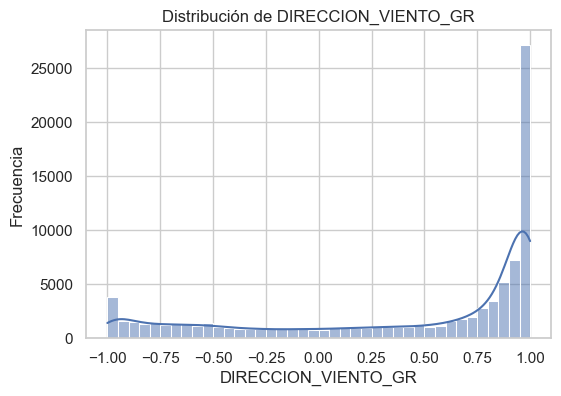

/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


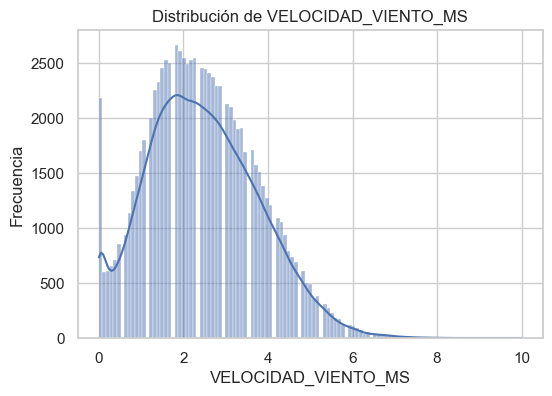

/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


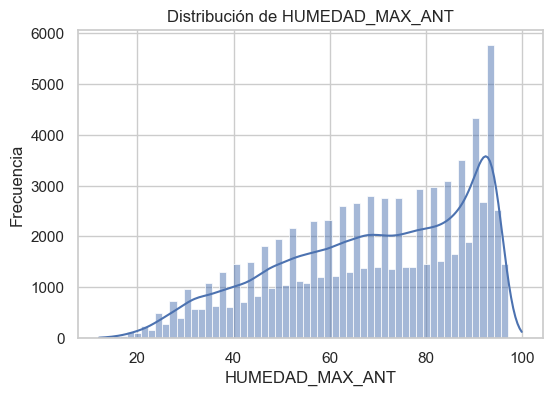

/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


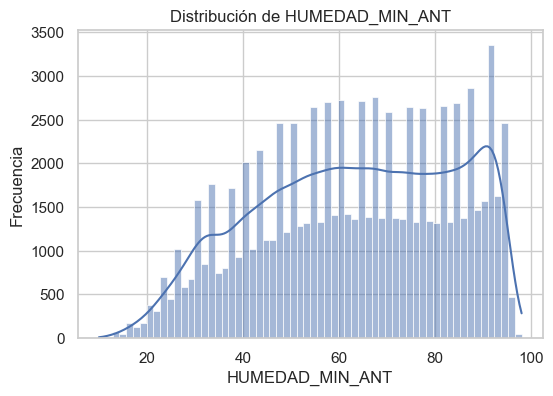

In [5]:
# HISTOGRAMAS DE VARIABLES NUMÉRICAS
vars_numericas = df.select_dtypes(include=np.number).columns[:4]

for col in vars_numericas:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

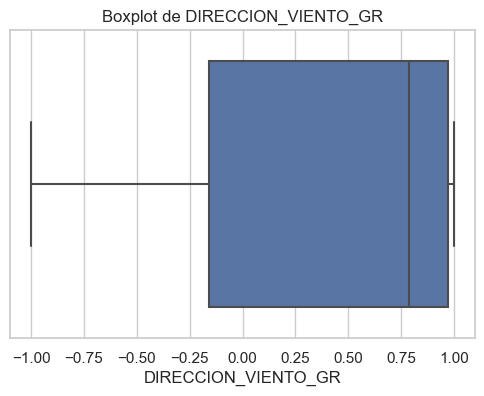

Asimetría (skew) de DIRECCION_VIENTO_GR: -0.86


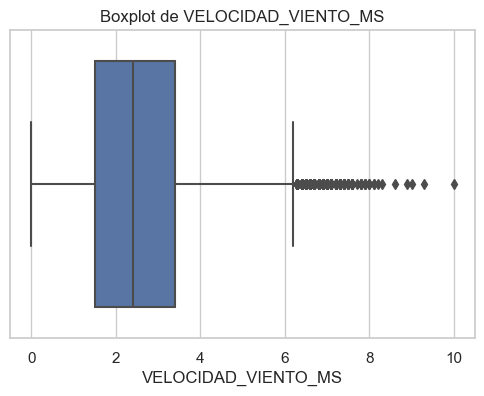

Asimetría (skew) de VELOCIDAD_VIENTO_MS: 0.37


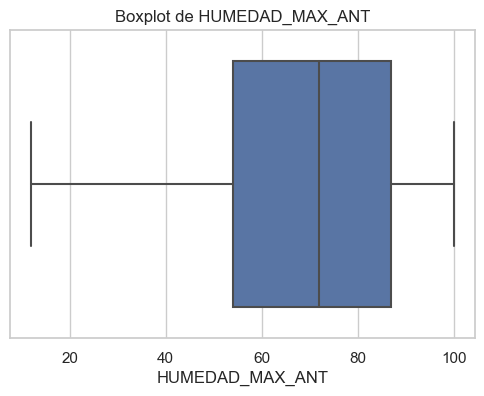

Asimetría (skew) de HUMEDAD_MAX_ANT: -0.48


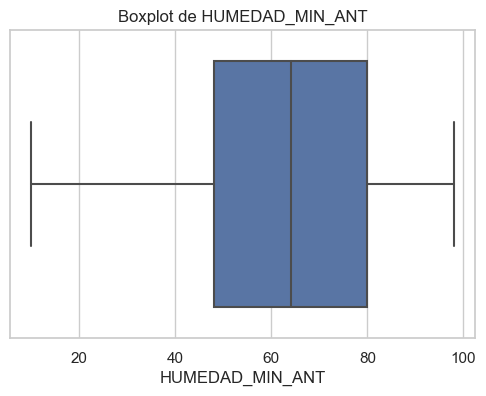

Asimetría (skew) de HUMEDAD_MIN_ANT: -0.23


In [6]:
# BOXPLOTS
for col in vars_numericas:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col].dropna())
    plt.title(f"Boxplot de {col}")
    plt.show()
    print(f"Asimetría (skew) de {col}: {skew(df[col].dropna()):.2f}")

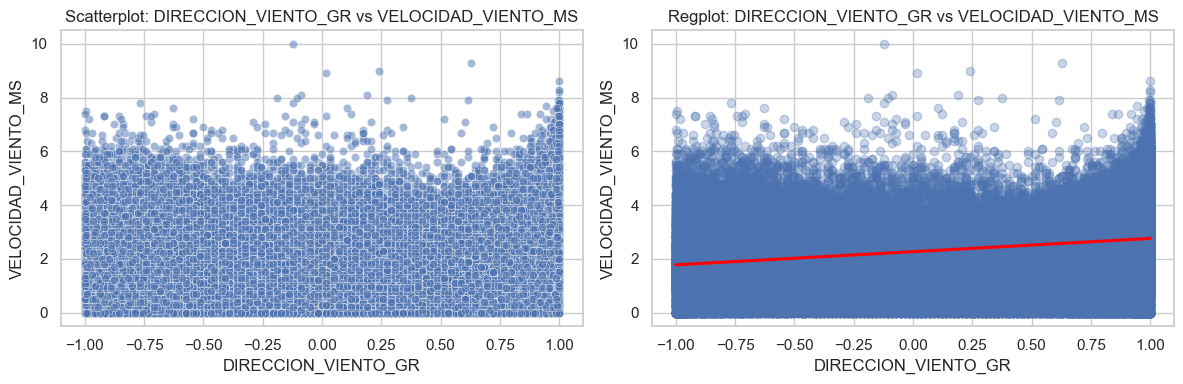

Correlación de Pearson entre DIRECCION_VIENTO_GR y VELOCIDAD_VIENTO_MS: 0.26



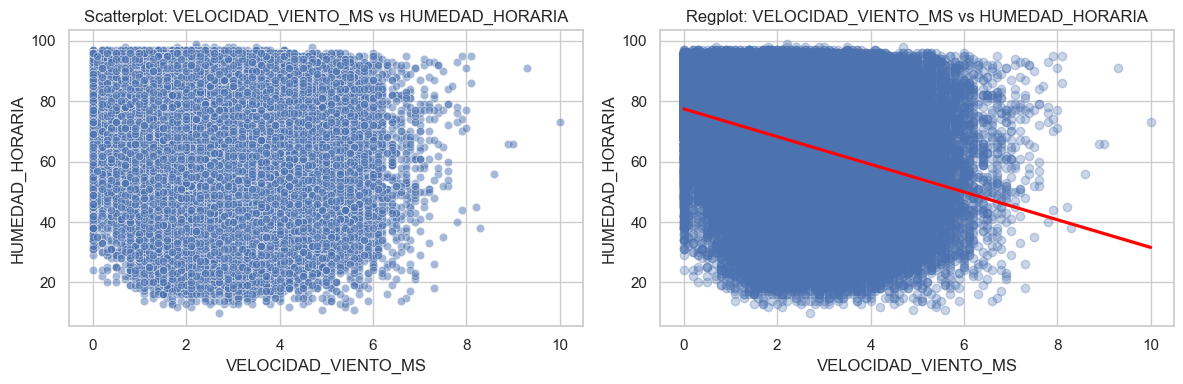

Correlación de Pearson entre VELOCIDAD_VIENTO_MS y HUMEDAD_HORARIA: -0.30



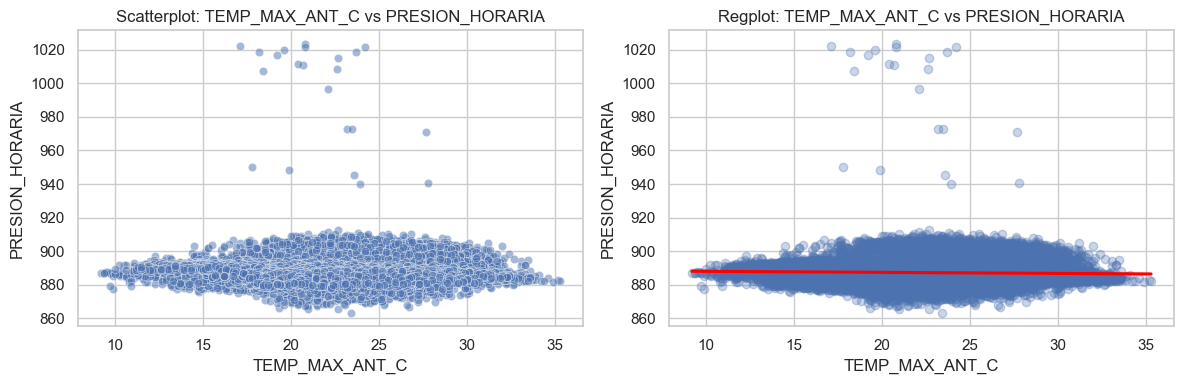

Correlación de Pearson entre TEMP_MAX_ANT_C y PRESION_HORARIA: -0.06



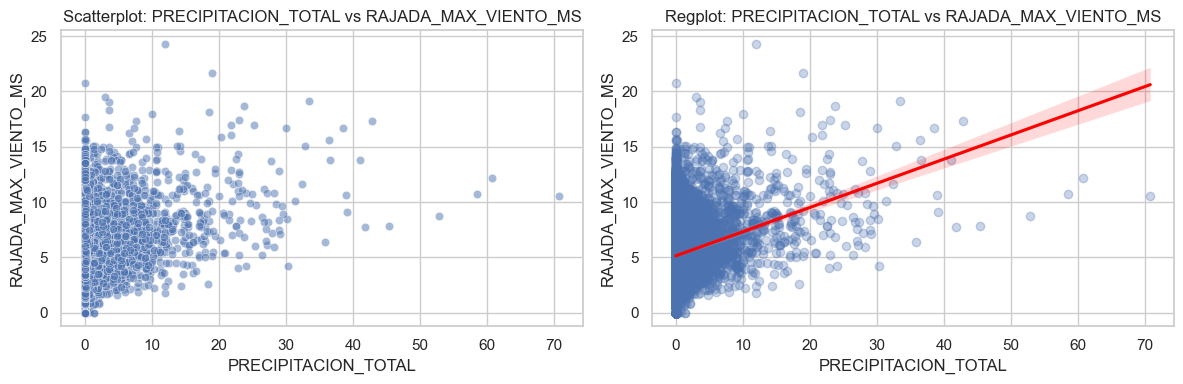

Correlación de Pearson entre PRECIPITACION_TOTAL y RAJADA_MAX_VIENTO_MS: 0.12



In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define aquí 4 pares de variables explicativas
pares = [
    ('DIRECCION_VIENTO_GR', 'VELOCIDAD_VIENTO_MS'),
    ('VELOCIDAD_VIENTO_MS', 'HUMEDAD_HORARIA'),
    ('TEMP_MAX_ANT_C', 'PRESION_HORARIA'),
    ('PRECIPITACION_TOTAL', 'RAJADA_MAX_VIENTO_MS')
]

# Itera sobre cada par y dibuja scatterplot y regplot
for x, y in pares:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Scatterplot puro
    sns.scatterplot(
        data=df,
        x=x,
        y=y,
        ax=axes[0],
        alpha=0.5
    )
    axes[0].set_title(f'Scatterplot: {x} vs {y}')
    axes[0].set_xlabel(x)
    axes[0].set_ylabel(y)

    # Regplot (scatter + línea de regresión)
    sns.regplot(
        data=df,
        x=x,
        y=y,
        ax=axes[1],
        scatter_kws={'alpha': 0.3},
        line_kws={'color': 'red'}
    )
    axes[1].set_title(f'Regplot: {x} vs {y}')
    axes[1].set_xlabel(x)
    axes[1].set_ylabel(y)

    plt.tight_layout()
    plt.show()

    # Análisis cualitativo breve
    corr = df[[x, y]].dropna().corr().iloc[0, 1]
    print(f"Correlación de Pearson entre {x} y {y}: {corr:.2f}\n")

# Detección de fraude

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.impute import SimpleImputer
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [4]:
# Cargar los archivos
train_transaction = pd.read_csv("train_transaction.csv")
train_identity = pd.read_csv("train_identity.csv")

# Unir por TransactionID
train_data = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')

# Verificar
print("Dimensiones del conjunto unido:", train_data.shape)
train_data.head()
print("\nTipo de cada columna:\n")
print(train_data.dtypes)

Dimensiones del conjunto unido: (590540, 434)

Tipo de cada columna:

TransactionID       int64
isFraud             int64
TransactionDT       int64
TransactionAmt    float64
ProductCD          object
                   ...   
id_36              object
id_37              object
id_38              object
DeviceType         object
DeviceInfo         object
Length: 434, dtype: object


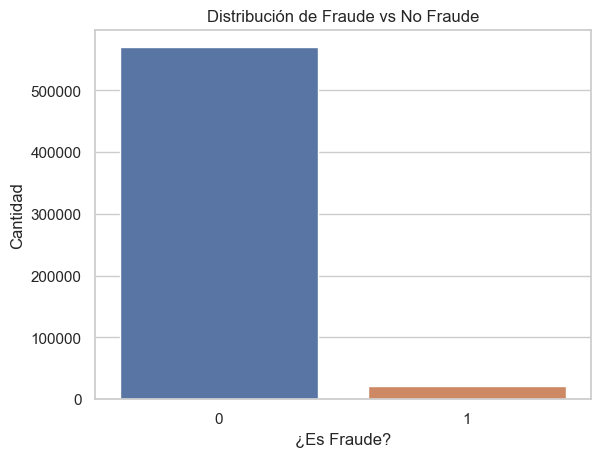

In [ ]:
sns.countplot(x='isFraud', data=train_data)
plt.title("Distribución de Fraude vs No Fraude")
plt.xlabel("¿Es Fraude?")
plt.ylabel("Cantidad")
plt.show()

In [18]:
# Conteo absoluto
conteo = train_data['isFraud'].value_counts()
print("Conteo de clases:\n", conteo)

# Porcentaje
porcentaje = train_data['isFraud'].value_counts(normalize=True) * 100
print("\nPorcentaje de clases:\n", porcentaje)

Conteo de clases:
 isFraud
0    569877
1     20663
Name: count, dtype: int64

Porcentaje de clases:
 isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


In [ ]:
# Cargar los archivos para test
test_transaction = pd.read_csv("test_transaction.csv")
test_identity = pd.read_csv("test_identity.csv")

# Unir por TransactionID
test_data = pd.merge(test_transaction, test_identity, on='TransactionID', how='left')

# Verificar
print("Dimensiones del conjunto unido:", test_data.shape)
test_data.head()
print("\nTipo de cada columna:\n")
print(test_data.dtypes)

Dimensiones del conjunto unido: (506691, 433)

Tipo de cada columna:

TransactionID       int64
TransactionDT       int64
TransactionAmt    float64
ProductCD          object
card1               int64
                   ...   
id-36              object
id-37              object
id-38              object
DeviceType         object
DeviceInfo         object
Length: 433, dtype: object


## Imputación

In [7]:

# Paso 1: Identificar variables numéricas (excluye 'isFraud')
numericas = train_data.select_dtypes(include='number').columns.drop('isFraud', errors='ignore')

# Paso 2: Imputar valores faltantes con la mediana
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(train_data[numericas]), columns=numericas)

# Paso 3: Eliminar variables altamente correlacionadas (> 0.90)
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
cols_correladas = [col for col in upper.columns if any(upper[col] > 0.90)]
X_filtrado = X.drop(columns=cols_correladas)

# Paso 4: Limitar a las primeras 50 columnas
X_reducido = X_filtrado.iloc[:, :50]

# Paso 5: Eliminar TODAS las variables con VIF ≥ 10 en un solo paso
def calcular_vif_una_vez(df, threshold=10):
    vif = pd.Series(
        [variance_inflation_factor(df.values, i) for i in range(df.shape[1])],
        index=df.columns
    )
    altas = vif[vif >= threshold].index.tolist()
    print(f"🗑️ Eliminando {len(altas)} variables con VIF ≥ {threshold}: {altas}")
    df_reducido = df.drop(columns=altas)
    return df_reducido, altas

# Ejecutar eliminación rápida
X_sin_colinealidad, columnas_eliminadas = calcular_vif_una_vez(X_reducido)

# Paso 6: Reagregar la variable objetivo
train_data_reducido = pd.concat([X_sin_colinealidad, train_data['isFraud'].reset_index(drop=True)], axis=1)

# Confirmación
print("✅ Dataset final:", train_data_reducido.shape)
print("🗑️ Variables eliminadas por VIF:", columnas_eliminadas)

🗑️ Eliminando 22 variables con VIF ≥ 10: ['TransactionID', 'card3', 'card5', 'addr1', 'addr2', 'C1', 'C5', 'C13', 'D9', 'V1', 'V2', 'V3', 'V4', 'V6', 'V7', 'V8', 'V9', 'V14', 'V23', 'V24', 'V25', 'V26']
✅ Dataset final: (590540, 29)
🗑️ Variables eliminadas por VIF: ['TransactionID', 'card3', 'card5', 'addr1', 'addr2', 'C1', 'C5', 'C13', 'D9', 'V1', 'V2', 'V3', 'V4', 'V6', 'V7', 'V8', 'V9', 'V14', 'V23', 'V24', 'V25', 'V26']


In [8]:
from sklearn.preprocessing import OneHotEncoder
from scipy.stats import chi2_contingency

# Paso 1: Seleccionar variables categóricas
categoricas = train_data.select_dtypes(include='object').columns

# Paso 2: Filtrar solo las que tienen pocas categorías únicas (evita explosión de columnas)
categoricas_bajas = [col for col in categoricas if train_data[col].nunique() <= 10]

# Paso 3: Analizar redundancia entre variables categóricas usando chi²
redundantes = []

for i in range(len(categoricas_bajas)):
    for j in range(i + 1, len(categoricas_bajas)):
        tabla = pd.crosstab(train_data[categoricas_bajas[i]], train_data[categoricas_bajas[j]])
        if tabla.shape[0] > 1 and tabla.shape[1] > 1:
            chi2, p, _, _ = chi2_contingency(tabla)
            if p < 0.01:  # asociación fuerte → posible redundancia
                redundantes.append((categoricas_bajas[i], categoricas_bajas[j], p))

# Mostrar pares redundantes
print("🔁 Posibles variables categóricas redundantes (p < 0.01):")
for par in redundantes:
    print(f"{par[0]}  ~  {par[1]} (p = {par[2]:.4f})")

🔁 Posibles variables categóricas redundantes (p < 0.01):
ProductCD  ~  card4 (p = 0.0000)
ProductCD  ~  card6 (p = 0.0000)
ProductCD  ~  M4 (p = 0.0000)
ProductCD  ~  id_12 (p = 0.0000)
ProductCD  ~  id_15 (p = 0.0000)
ProductCD  ~  id_16 (p = 0.0000)
ProductCD  ~  id_23 (p = 0.0000)
ProductCD  ~  id_27 (p = 0.0003)
ProductCD  ~  id_28 (p = 0.0000)
ProductCD  ~  id_29 (p = 0.0000)
ProductCD  ~  id_34 (p = 0.0000)
ProductCD  ~  id_35 (p = 0.0000)
ProductCD  ~  id_36 (p = 0.0000)
ProductCD  ~  id_37 (p = 0.0000)
ProductCD  ~  id_38 (p = 0.0000)
ProductCD  ~  DeviceType (p = 0.0000)
card4  ~  card6 (p = 0.0000)
card4  ~  M2 (p = 0.0000)
card4  ~  M3 (p = 0.0001)
card4  ~  M4 (p = 0.0000)
card4  ~  M5 (p = 0.0000)
card4  ~  M6 (p = 0.0000)
card4  ~  M7 (p = 0.0000)
card4  ~  M8 (p = 0.0028)
card4  ~  M9 (p = 0.0000)
card4  ~  id_12 (p = 0.0000)
card4  ~  id_15 (p = 0.0000)
card4  ~  id_16 (p = 0.0000)
card4  ~  id_23 (p = 0.0000)
card4  ~  id_27 (p = 0.0000)
card4  ~  id_28 (p = 0.0000)
ca

In [ ]:
# Paso 4: Elegir solo las no redundantes para codificar
# (manual o automática según las pruebas anteriores)
categoricas_a_codificar = list(set(categoricas_bajas) - set([r[1] for r in redundantes]))

# Paso 5: Codificar usando OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)
encoded = encoder.fit_transform(train_data[categoricas_a_codificar])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categoricas_a_codificar))

# Paso 6: Integrar al conjunto final
train_final = pd.concat([
    train_data_reducido.reset_index(drop=True).drop(columns=categoricas_a_codificar, errors='ignore'),
    encoded_df.reset_index(drop=True)
], axis=1)

print("Dataset final con categóricas codificadas:", train_final.shape)

/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


✅ Dataset final con categóricas codificadas: (590540, 37)


In [13]:
print("Dimensiones finales:", train_final.shape)
print("Columnas finales:\n", train_final.columns.tolist())
train_final.head()

Dimensiones finales: (590540, 37)
Columnas finales:
 ['TransactionAmt', 'card1', 'card2', 'dist1', 'dist2', 'C3', 'D1', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'V10', 'V12', 'V15', 'V17', 'V19', 'V27', 'V29', 'V35', 'V37', 'isFraud', 'ProductCD_C', 'ProductCD_H', 'ProductCD_R', 'ProductCD_S', 'ProductCD_W', 'M1_F', 'M1_T', 'M1_nan']


,TransactionAmt,card1,card2,dist1,dist2,C3,D1,D3,D4,D5,...,V37,isFraud,ProductCD_C,ProductCD_H,ProductCD_R,ProductCD_S,ProductCD_W,M1_F,M1_T,M1_nan
0,68.5,13926.0,361.0,19.0,37.0,0.0,14.0,13.0,26.0,10.0,...,1.0,0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,29.0,2755.0,404.0,8.0,37.0,0.0,0.0,8.0,0.0,10.0,...,1.0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,59.0,4663.0,490.0,287.0,37.0,0.0,0.0,8.0,0.0,10.0,...,1.0,0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,50.0,18132.0,567.0,8.0,37.0,0.0,112.0,0.0,94.0,0.0,...,1.0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,50.0,4497.0,514.0,8.0,37.0,0.0,0.0,8.0,26.0,10.0,...,1.0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [14]:
train_final.describe(include='all')

,TransactionAmt,card1,card2,dist1,dist2,C3,D1,D3,D4,D5,...,V37,isFraud,ProductCD_C,ProductCD_H,ProductCD_R,ProductCD_S,ProductCD_W,M1_F,M1_T,M1_nan
count,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,...,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000
mean,135.027176,9898.734658,362.531959,52.585031,49.415459,0.005644,94.151273,19.287537,107.392422,25.370124,...,1.077145,0.034990,0.116028,0.055922,0.063838,0.019690,0.744522,0.000042,0.540886,0.459071
std,239.162522,4901.170153,156.595356,242.353179,141.769757,0.150536,157.547693,47.556448,169.488426,63.449427,...,0.585511,0.183755,0.320258,0.229771,0.244465,0.138934,0.436130,0.006506,0.498326,0.498322
min,0.251000,1000.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-122.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,43.321000,6019.000000,215.000000,8.000000,37.000000,0.000000,0.000000,7.000000,0.000000,10.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,68.769000,9678.000000,361.000000,8.000000,37.000000,0.000000,3.000000,8.000000,26.000000,10.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
75%,125.000000,14184.000000,512.000000,8.000000,37.000000,0.000000,121.000000,11.000000,123.000000,10.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
max,31937.391000,18396.000000,600.000000,10286.000000,11623.000000,26.000000,640.000000,819.000000,869.000000,819.000000,...,54.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [15]:
train_final['isFraud'].value_counts(normalize=True) * 100

isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64

In [17]:
from imblearn.over_sampling import SMOTE

# Separar X e y desde train_final
X_train = train_final.drop(columns=['isFraud'])
y_train = train_final['isFraud']

# Aplicar SMOTE solo al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Verificar balance después del SMOTE
print("Distribución de clases después de SMOTE:")
print(y_train_res.value_counts(normalize=True))

Distribución de clases después de SMOTE:
isFraud
0    0.5
1    0.5
Name: proportion, dtype: float64


TEST
